In [1]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [2]:

# outfig_dir = Path('talk_figs/mcdermott_update/figs')
# outfig_dir.mkdir(parents=True, exist_ok=True)


In [25]:
def get_category_accuracies(predictions,labels,target):
    """
    Returns the accuracy for target category.
    """
    correct = 0
    total = 0
    for idx in range(len(labels)):
        label = labels[idx]
        if label==target:
            prediction = predictions[idx]
            if label==prediction:
                correct = correct+1
            total = total+1
    return correct/total


def format_model_str(path):
    path_str = str(path)
    path_stem = Path(path).stem
    
    # Split filename: model_config_nsynth_task_linear_eval_task_layer_other_modifiers.pkl
    # Example: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only_nsynth_family_linear_eval_family_relu4_full_rep_AdamW_0.005
    
    # 1. Extract architecture
    arch_match = re.search(r'(kell2018|resnet\d+|byol-a|byola)', path_str, re.IGNORECASE)
    arch = arch_match.group(1).lower() if arch_match else 'unknown'
    if arch == 'byola':
        arch = 'byol-a'
    
    # 2. Extract model config part (before _nsynth_)
    nsynth_idx = path_stem.find('_nsynth_')
    if nsynth_idx == -1:
        # Fallback: try to find where the model config ends
        model_config_part = path_stem
    else:
        model_config_part = path_stem[:nsynth_idx]
    
    # 3. Extract test layer from after _linear_eval_
    test_layer = 'unknown'
    linear_eval_idx = path_stem.find('_linear_eval_')
    if linear_eval_idx != -1:
        # Get the part after _linear_eval_
        after_linear_eval = path_stem[linear_eval_idx + len('_linear_eval_'):]
        # Split by underscores and find the layer (usually after task name)
        parts = after_linear_eval.split('_')
        # Layer is typically after the task name (e.g., family_relu4_full_rep_...)
        # Common layers to look for
        layer_patterns = [
            'relu0', 'relu1', 'relu2', 'relu3', 'relu4', 'relufc',
            'conv0', 'conv1', 'conv2', 'conv3', 'conv4',
            'maxpool0', 'maxpool1',
            'batchnorm0', 'batchnorm1', 'batchnorm2',
            'avgpool', 'fullyconnected', 'dropout',
            'layer1', 'layer2', 'layer3', 'layer4',
            'bn1', 'conv1_relu1', 'maxpool1',
            'final'
        ]
        for part in parts:
            if part in layer_patterns:
                test_layer = part
                break
        # If no layer found, try the second or third part (after task)
        if test_layer == 'unknown' and len(parts) > 1:
            # Skip common task names and modifiers
            skip_words = ['family', 'pitch', 'instrument', 'full', 'rep', 'AdamW', 'LARS', 'SGD']
            for part in parts[1:]:
                if part not in skip_words and not part.replace('.', '').isdigit():
                    test_layer = part
                    break
    
    # 4. Extract equivariant lambda from model config part
    eq_lambda = ''
    if 'equivariant' in model_config_part or 'eq_lmbda' in model_config_part:
        lambda_match = re.search(r'eq_lmbda_([-\d.e]+)', model_config_part)
        if lambda_match:
            lambda_val = lambda_match.group(1)
            # Convert scientific notation to float, then format
            try:
                eq_lambda = str(float(lambda_val))
            except:
                eq_lambda = lambda_val
    
    # 5. Determine SSL or supervised
    ssl_keywords = ['barlow', 'mmcr', 'invariant', 'equivariant']
    is_ssl = any(k in model_config_part for k in ssl_keywords)
    
    # 6. Determine if dual
    is_dual = 'dual' in model_config_part or 'dualtask' in model_config_part
    
    # 7. Task modifiers
    modifiers = []
    if 'word_speaker_audioset' in model_config_part:
        modifiers.append('multi-task')
    elif 'word_speaker' in model_config_part:
        modifiers.append('word speaker')
    elif 'word' in model_config_part and 'word_speaker' not in model_config_part:
        modifiers.append('word')
    elif 'jsin' in model_config_part:
        modifiers.append('jsin audioset')
    elif 'audioset' in model_config_part:
        modifiers.append('audioset')
    
    # 8. Compose task string
    task_parts = []
    if is_ssl:
        if is_dual:
            task_parts.append('ssl dual')
        elif eq_lambda:
            task_parts.append('ssl eq')
        else:
            task_parts.append('ssl')
        
        # Add base modifier if not multi-task
        if 'multi-task' not in modifiers:
            task_parts.extend(modifiers)  # e.g., word, audioset
    else:
        task_parts.append('supervised')
        task_parts.extend(modifiers)
    
    # Append eq_lambda if applicable
    if eq_lambda:
        task_parts.append(f'λ={eq_lambda}')
    
    task = ' '.join(task_parts)
    
    # 9. Data augmentations
    aug_str = ''
    if 'paired_augmentations' in model_config_part or ('resnet18' in arch and 'w_invar_aug' not in model_config_part):
        aug_str = 'paired augmentations'
    elif 'no_shared_fg_augments' in model_config_part:
        aug_str = 'unpaired augs'
    
    # 10. Full model name
    model_name = f"{arch} {task}"
    if aug_str:
        model_name = f"{model_name} {aug_str}"
    
    return model_name, arch, test_layer, eq_lambda




## Get Nsynth results for each model

In [29]:
path_to_nsynth_results = Path("eval_nsynth_results")

all_model_results = list(path_to_nsynth_results.rglob("audioset_*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("resnet18_barlow*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("resnet50_barlow*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("kell2018*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("word_kell2018*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("config_linear*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("byola*nsynth*.pkl"))
# all_model_results

test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]
                
resnet18_layer_order = [
                'preproc',
                'conv1',
                'bn1',
                'relu1',
                'maxpool1',
                'layer1',
                'layer2',
                'layer3',
                'layer4',
                'avgpool',
            ]            
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    results = pd.read_pickle(results_path)
    overall_acc = results['top1_mean']

    model_name, arch_class, test_layer, eq_lmbda = format_model_str(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)


    df_list.append(data)

nsynth_df = pd.DataFrame.from_records(df_list)
nsynth_df['test_layer'] = nsynth_df['test_layer'].astype('str')

nsynth_df = nsynth_df.loc[nsynth_df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

In [30]:
nsynth_df

,model_name,arch_class,test_layer,eq_lmbda,overall_acc
0,kell2018 supervised audioset,kell2018,relu4,,0.661865
1,kell2018 ssl eq audioset λ=0.5,kell2018,relu4,0.5,0.701172
2,kell2018 ssl eq audioset λ=0.0,kell2018,relu4,0.0,0.700195
3,kell2018 supervised multi-task,kell2018,relu4,,0.691162
4,kell2018 supervised word,kell2018,relu4,,0.669189


/tmp/ipykernel_3683241/3655547353.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order, rotation=90, ) #ha='right', rotation_mode='anchor')


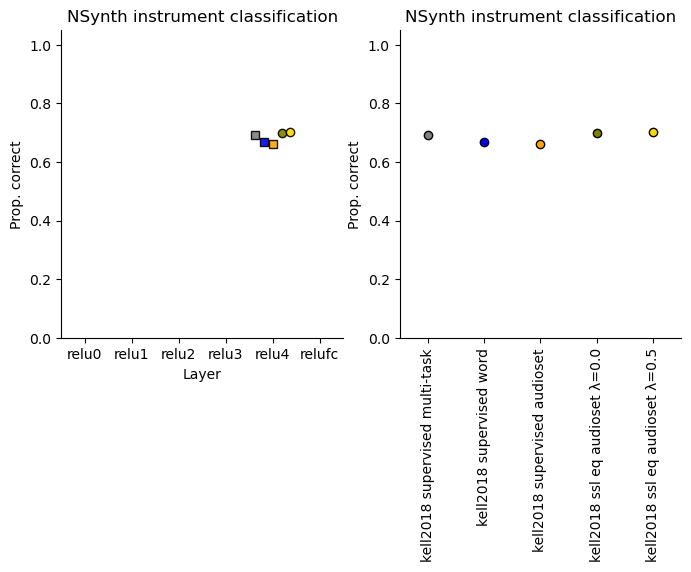

In [36]:
hue_order = [
    # Supervised
    'kell2018 supervised multi-task',
    'kell2018 supervised word',
    'kell2018 supervised audioset',

    # SSL / Invariant
    # 'kell2018 ssl word',

    # # SSL / Equivariant
    # 'kell2018 ssl eq λ=0.1',
    # 'kell2018 ssl eq λ=0.2',
    # 'kell2018 ssl eq λ=0.3',
    # 'kell2018 ssl eq λ=0.4',
    # 'kell2018 ssl eq λ=0.5',
    'kell2018 ssl eq audioset λ=0.0',  
    'kell2018 ssl eq audioset λ=0.5',  
    # 'kell2018 ssl jsin audioset',

#     # SSL / Dual
#     'kell2018 ssl dual λ=0.0',
#     'kell2018 ssl dual λ=0.0 unpaired augs',
#     'kell2018 ssl dual λ=0.01',
#     'kell2018 ssl dual λ=0.1',
#     'kell2018 ssl dual λ=0.5',
]

marker_palette = ['s' if 'supervised' in model else 'o' for model in hue_order]
             
              

# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 ssl eq audioset λ=0.0'] = 'olive' 
hue_dict['kell2018 ssl eq audioset λ=0.5'] = 'gold' 
hue_dict['kell2018 ssl jsin audioset'] = 'gold' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 ssl word'] = 'magenta'
hue_dict['kell2018 ssl dual λ=0.0'] = 'purple'
hue_dict['kell2018 ssl dual λ=0.0 unpaired augs'] = 'red'
# hue_dict['kell2018 dual equivariant 5e-01'] = 'olive'

layer_order = [
            'relu0', 'relu1', 'relu2', 'relu3', 'relu4', 'relufc'
]

# eq_model_list = hue_order[4:9]
# equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
# equi_color_dict = dict(zip(eq_model_list, equi_palette))

# dual_equi_model_list = hue_order[-3:]
# dual_equi_palette = sns.color_palette("Blues", n_colors=len(dual_equi_model_list)) 
# dual_equi_color_dict = dict(zip(dual_equi_model_list, dual_equi_palette))

hue_dict = {**hue_dict,} #  **equi_color_dict, **dual_equi_color_dict}

nsynth_to_plot = nsynth_df[(nsynth_df.arch_class == 'kell2018') & (~nsynth_df.overall_acc.isna()) & (nsynth_df.test_layer.str.contains('relu'))]

fig, axes = plt.subplots(1,2,figsize=(8,4))

g = sns.pointplot(data=nsynth_to_plot, 
                order=layer_order,
                hue='model_name', y='overall_acc', #col='arch_class',
                x="test_layer",
                palette=hue_dict,
                hue_order=hue_order,
                alpha=0.9,
                dodge=0.75,
                ax = axes[0],
                legend=False,
                markers=marker_palette,
            # ls='',
                mec='k',
                mew=1,
                lw=1, ms=6
                #  height=4, 
                 )
g.set(ylim=(0, 1.05), title="NSynth instrument classification", ylabel='Prop. correct', xlabel='Layer')

test_layers = ['relu4', 'final', 'avgpool']

to_plot = nsynth_to_plot[(nsynth_to_plot.model_name.isin(hue_order)) & nsynth_to_plot.test_layer.isin(test_layers)]
to_plot = to_plot[~((to_plot.model_name.str.contains('kell')) & to_plot.test_layer.str.contains('avgpool'))]
# models_for_esc = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# nsynth_to_plot = nsynth_to_plot[nsynth_to_plot.model_name.str.contains('kell2018|byola')]
g = sns.pointplot(data=to_plot,
                order=hue_order,
                x='model_name',
                y='overall_acc',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,
                # markers=marker_palette,
                # hue_order=hue_order,
                # height=4,
                ax = axes[1],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=hue_order, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0., 1.05), title="NSynth instrument classification", ylabel='Prop. correct', xlabel='')
sns.despine()
